# 환경설정

In [ ]:
!pip install -q 'qai-hub-models[facemap-3dmm]'
!pip install -q insightface onnxruntime-gpu opencv-python-headless
print('✅ 설치 완료')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.6/103.6 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
os.makedirs('/root/.insightface/models', exist_ok=True)
INSWAPPER_PATH = '/root/.insightface/models/inswapper_128.onnx'
if not os.path.exists(INSWAPPER_PATH):
    print('⬇ inswapper_128.onnx 다운로드 중... (~500MB)')
    !wget -q --show-progress \
        -O {INSWAPPER_PATH} \
        https://huggingface.co/ezioruan/inswapper_128.onnx/resolve/main/inswapper_128.onnx
    print('✅ 다운로드 완료')
else:
    print('✅ inswapper_128.onnx 이미 존재')

⬇ inswapper_128.onnx 다운로드 중... (~500MB)
/root/.insightface/ 100%[===================>] 528.58M   304MB/s    in 1.7s    
✅ 다운로드 완료


# 모델 로드 및 함수 정의

In [ ]:
import torch
import numpy as np
import cv2
import warnings
warnings.filterwarnings('ignore')

from qai_hub_models.models.facemap_3dmm import Model as FaceMap3DMM

print('facemap_3dmm 로드 중...')
facemap_model = FaceMap3DMM.from_pretrained()
facemap_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
facemap_model = facemap_model.to(device)
print(f'✅ facemap_3dmm 로드 완료 | device: {device}')

import insightface
from insightface.app import FaceAnalysis
face_app = FaceAnalysis(
    name='buffalo_l',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
face_app.prepare(ctx_id=0, det_size=(640, 640))
swapper = insightface.model_zoo.get_model(INSWAPPER_PATH, download=False)
print('✅ InsightFace 초기화 완료')

facemap_3dmm 로드 중...


✅ facemap_3dmm 로드 완료 | device: cuda
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 96048.98KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [ ]:
# ──────────────────────────────────────────────────────────
# facemap_3dmm 출력 shape 디버깅 유틸
# 모델 출력이 어떤 shape인지 먼저 확인해야 올바르게 파싱 가능
# ──────────────────────────────────────────────────────────
INPUT_SIZE = 128

def preprocess_for_facemap(img_bgr, face_bbox=None):
    h, w = img_bgr.shape[:2]
    if face_bbox is not None:
        x1, y1, x2, y2 = [int(v) for v in face_bbox]
        pad_x = int((x2 - x1) * 0.2)
        pad_y = int((y2 - y1) * 0.2)
        x1 = max(0, x1 - pad_x); y1 = max(0, y1 - pad_y)
        x2 = min(w, x2 + pad_x); y2 = min(h, y2 + pad_y)
        crop = img_bgr[y1:y2, x1:x2]
        offset_xy = (x1, y1)
        crop_wh = (x2 - x1, y2 - y1)
    else:
        crop = img_bgr
        offset_xy = (0, 0)
        crop_wh = (w, h)
    resized = cv2.resize(crop, (INPUT_SIZE, INPUT_SIZE))
    scale_xy = (crop_wh[0] / INPUT_SIZE, crop_wh[1] / INPUT_SIZE)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    normalized = (rgb - 0.5) / 0.5
    tensor = torch.from_numpy(normalized.transpose(2, 0, 1)).unsqueeze(0).to(device)
    return tensor, scale_xy, offset_xy


def debug_facemap_output(img_bgr, face_bbox=None):
    """
    facemap_3dmm 출력 shape를 확인하는 디버그 함수
    → 이 결과를 보고 postprocess_landmarks 파싱 방식을 결정
    """
    tensor, scale_xy, offset_xy = preprocess_for_facemap(img_bgr, face_bbox)
    with torch.no_grad():
        output = facemap_model(tensor)

    print('=== facemap_3dmm 출력 디버그 ===')
    if isinstance(output, (tuple, list)):
        print(f'출력 타입: {type(output)} (길이={len(output)})')
        for i, o in enumerate(output):
            if hasattr(o, 'shape'):
                arr = o.detach().cpu().numpy()
                print(f'  output[{i}]: shape={arr.shape}, dtype={arr.dtype}')
                print(f'             min={arr.min():.4f}, max={arr.max():.4f}')
                print(f'             flat sample (first 10): {arr.flatten()[:10]}')
    else:
        arr = output.detach().cpu().numpy()
        print(f'출력 타입: tensor, shape={arr.shape}, dtype={arr.dtype}')
        print(f'min={arr.min():.4f}, max={arr.max():.4f}')
        print(f'flat sample (first 10): {arr.flatten()[:10]}')
    return output, scale_xy, offset_xy

print('✅ 디버그 함수 정의 완료')

✅ 디버그 함수 정의 완료


# STEP 0 : 소스 이미지 & 원본 driving 영상 업로드 + 출력 shape 확인

In [ ]:
from google.colab import files
import glob, time

print('📁 소스 이미지 업로드 (얼굴을 가져올 이미지)')
src_upload = files.upload()
src_path = list(src_upload.keys())[0]

print('\n📁 원본 driving 영상 업로드 (모자이크 없는 버전)')
orig_upload = files.upload()
orig_video_path = list(orig_upload.keys())[0]

print('\n📁 모자이크 driving 영상 업로드 (합성 배경으로 사용)')
mosaic_upload = files.upload()
mosaic_video_path = list(mosaic_upload.keys())[0]

src_img = cv2.imread(src_path)
assert src_img is not None, '소스 이미지 로드 실패'

# 영상 정보
cap = cv2.VideoCapture(orig_video_path)
fps          = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ret, first_frame = cap.read()
cap.release()

print(f'\n✅ 원본 영상 정보: {width}x{height} | {fps:.2f}fps | {total_frames}프레임 ({total_frames/fps:.1f}초)')

# 작업 폴더
WORK_DIR     = '/content/video_faceswap'
FRAMES_ORIG  = f'{WORK_DIR}/frames_original'   # 원본 driving 프레임
FRAMES_MOSAIC= f'{WORK_DIR}/frames_mosaic'     # 모자이크 driving 프레임
LANDMARK_DIR = f'{WORK_DIR}/landmarks'          # 랜드마크 txt
SWAPPED_DIR  = f'{WORK_DIR}/frames_swapped'    # 최종 합성 프레임
for d in [WORK_DIR, FRAMES_ORIG, FRAMES_MOSAIC, LANDMARK_DIR, SWAPPED_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'✅ 작업 디렉토리 생성: {WORK_DIR}')

📁 소스 이미지 업로드 (얼굴을 가져올 이미지)


Saving front.png to front.png

📁 원본 driving 영상 업로드 (모자이크 없는 버전)


Saving output_keyframe (16).mp4 to output_keyframe (16).mp4

📁 모자이크 driving 영상 업로드 (합성 배경으로 사용)


Saving output_keyframe (16).mp4 to output_keyframe (16) (1).mp4

✅ 원본 영상 정보: 1920x1080 | 29.59fps | 577프레임 (19.5초)
✅ 작업 디렉토리 생성: /content/video_faceswap


In [ ]:
# ── 첫 프레임으로 facemap_3dmm 출력 shape 확인 ──────────────
# 이 셀을 반드시 실행하고 출력을 확인한 뒤 다음 셀로 진행
print('🔍 facemap_3dmm 출력 shape 확인 (첫 프레임 사용)...')
tgt_faces_debug = face_app.get(first_frame)
bbox_debug = tgt_faces_debug[0].bbox if tgt_faces_debug else None
print(f'  InsightFace 얼굴 감지: {len(tgt_faces_debug)}개 | bbox={bbox_debug}')

raw_output, scale_xy_dbg, offset_xy_dbg = debug_facemap_output(first_frame, face_bbox=bbox_debug)
print('\n위 출력을 확인하고 아래 NUM_LANDMARKS 값을 설정하세요.')

🔍 facemap_3dmm 출력 shape 확인 (첫 프레임 사용)...
  InsightFace 얼굴 감지: 2개 | bbox=[294.6824  257.9753  696.44446 721.1054 ]
=== facemap_3dmm 출력 디버그 ===
출력 타입: tensor, shape=(1, 265), dtype=float32
min=-2.4146, max=4.4574
flat sample (first 10): [-7.5230289e-01 -4.4348562e-01  9.8083802e-02  1.0026860e-01
 -9.3575567e-03 -5.7261556e-02  1.3992205e-02 -5.7093866e-02
  5.4388389e-02 -4.6213530e-04]

위 출력을 확인하고 아래 NUM_LANDMARKS 값을 설정하세요.


In [ ]:
# ── 위 디버그 출력을 보고 파싱 함수를 설정 ──────────────────
#
# facemap_3dmm 출력 shape 케이스별 파싱:
#   (1, 68, 2)  → xy = output.reshape(-1, 2)         → 68개
#   (1, 136)    → xy = output.reshape(-1, 2)          → 68개
#   (1, 1, 136) → xy = output.reshape(-1, 2)          → 68개
#   (1, N, 3)   → xy = output.reshape(-1,3)[:,:2]     → N개 (z 제거)
#   기타        → flatten 후 reshape(-1, 2) 시도
#
# ── 아래 설정값: 위 디버그 결과에 맞게 수정 ─────────────────
EXPECTED_LANDMARKS = 68   # 예상 랜드마크 수 (보통 68)
OUTPUT_HAS_Z = False       # z좌표 포함 여부 (출력 마지막 dim이 3이면 True)
OUTPUT_INDEX = 0           # tuple 출력일 때 사용할 인덱스 (보통 0)
# ─────────────────────────────────────────────────────────────


def postprocess_landmarks(output, scale_xy, offset_xy):
    """
    facemap_3dmm 출력 → 원본 이미지 좌표 랜드마크 (N, 2)
    shape 자동 파싱: (1,68,2), (1,136), (1,1,136), (1,N,3) 모두 처리
    """
    if isinstance(output, (tuple, list)):
        lm_tensor = output[OUTPUT_INDEX]
    else:
        lm_tensor = output

    arr = lm_tensor.detach().cpu().numpy()
    flat = arr.flatten()

    if OUTPUT_HAS_Z:
        # z 포함 → reshape(-1, 3) → 앞 2열만
        total = len(flat)
        n = total // 3
        xy = flat[:n*3].reshape(n, 3)[:, :2]
    else:
        # xy만 → reshape(-1, 2)
        total = len(flat)
        n = total // 2
        xy = flat[:n*2].reshape(n, 2)

    # 실제로 EXPECTED_LANDMARKS개가 나왔는지 확인
    if len(xy) != EXPECTED_LANDMARKS:
        # 경고만 출력, 중단하지 않음
        pass

    # 128x128 좌표 → 원본 이미지 좌표
    sx, sy = scale_xy
    ox, oy = offset_xy
    xy = xy.astype(np.float32).copy()
    xy[:, 0] = xy[:, 0] * sx + ox
    xy[:, 1] = xy[:, 1] * sy + oy
    return xy


def landmarks_to_5kps(lm):
    n = len(lm)
    if n == 68:
        re = lm[36:42].mean(0); le = lm[42:48].mean(0)
        nt = lm[30]; rm = lm[48]; lm_ = lm[54]
    elif n >= 5:
        def idx(r): return int(n * r)
        re = lm[idx(0.28):idx(0.38)].mean(0)
        le = lm[idx(0.38):idx(0.48)].mean(0)
        nt = lm[idx(0.44)]
        rm = lm[idx(0.60)]
        lm_ = lm[idx(0.70)]
    else:
        return np.full((5, 2), np.nan, dtype=np.float32)
    return np.array([re, le, nt, rm, lm_], dtype=np.float32)


def is_valid_kps_5(kps):
    return kps is not None and kps.shape == (5, 2) and \
           not np.any(np.isnan(kps)) and not np.any(np.isinf(kps))


# ── 파싱 검증 ──────────────────────────────────────────────
lm_test = postprocess_landmarks(raw_output, scale_xy_dbg, offset_xy_dbg)
kps_test = landmarks_to_5kps(lm_test)
print(f'✅ 랜드마크 파싱 검증: {len(lm_test)}개 | kps_5 유효={is_valid_kps_5(kps_test)}')
print(f'   x범위: {lm_test[:,0].min():.1f}~{lm_test[:,0].max():.1f}')
print(f'   y범위: {lm_test[:,1].min():.1f}~{lm_test[:,1].max():.1f}')
if len(lm_test) != EXPECTED_LANDMARKS:
    print(f'⚠️  예상({EXPECTED_LANDMARKS})과 실제({len(lm_test)}) 랜드마크 수 불일치!')
    print('   → OUTPUT_HAS_Z 또는 OUTPUT_INDEX 값을 조정하세요.')

✅ 랜드마크 파싱 검증: 132개 | kps_5 유효=True
   x범위: 203.4~214.9
   y범위: 156.7~166.0
⚠️  예상(68)과 실제(132) 랜드마크 수 불일치!
   → OUTPUT_HAS_Z 또는 OUTPUT_INDEX 값을 조정하세요.


# STEP 1 : 영상 → 프레임 분리

In [ ]:
def extract_frames(video_path, out_dir, label=''):
    cap = cv2.VideoCapture(video_path)
    n = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        cv2.imwrite(f'{out_dir}/frame_{n:06d}.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        n += 1
        if n % 100 == 0: print(f'  {label} {n}프레임 저장...')
    cap.release()
    return n

print('🎬 원본 driving 영상 프레임 분리...')
n1 = extract_frames(orig_video_path, FRAMES_ORIG, '[원본]')
print(f'✅ 원본: {n1}프레임')

print('\n🎬 모자이크 driving 영상 프레임 분리...')
n2 = extract_frames(mosaic_video_path, FRAMES_MOSAIC, '[모자이크]')
print(f'✅ 모자이크: {n2}프레임')

if n1 != n2:
    print(f'⚠️  프레임 수 불일치: 원본={n1}, 모자이크={n2} → 짧은 쪽 기준으로 처리됩니다')
total_frames = min(n1, n2)

🎬 원본 driving 영상 프레임 분리...
  [원본] 100프레임 저장...
  [원본] 200프레임 저장...
  [원본] 300프레임 저장...
  [원본] 400프레임 저장...
  [원본] 500프레임 저장...
✅ 원본: 577프레임

🎬 모자이크 driving 영상 프레임 분리...
  [모자이크] 100프레임 저장...
  [모자이크] 200프레임 저장...
  [모자이크] 300프레임 저장...
  [모자이크] 400프레임 저장...
  [모자이크] 500프레임 저장...
✅ 모자이크: 577프레임


# STEP 2 : 원본 프레임에서 랜드마크 추출 → txt 저장

In [ ]:
orig_paths = sorted(glob.glob(f'{FRAMES_ORIG}/frame_*.jpg'))
print(f'📍 {len(orig_paths)}개 원본 프레임에서 랜드마크 추출 시작...\n')

t0 = time.time()
no_face_count = 0
bad_lm_count  = 0

for i, fpath in enumerate(orig_paths):
    frame = cv2.imread(fpath)
    frame_name = os.path.splitext(os.path.basename(fpath))[0]
    txt_path = f'{LANDMARK_DIR}/{frame_name}.txt'

    # InsightFace 얼굴 감지 (bbox 참조)
    faces = face_app.get(frame)
    insightface_face = faces[0] if faces else None
    bbox = insightface_face.bbox if insightface_face is not None else None

    # facemap_3dmm 랜드마크 추출
    tensor, scale_xy, offset_xy = preprocess_for_facemap(frame, face_bbox=bbox)
    with torch.no_grad():
        output = facemap_model(tensor)
    lm = postprocess_landmarks(output, scale_xy, offset_xy)
    kps = landmarks_to_5kps(lm)

    face_detected = int(len(faces) > 0)
    lm_valid = int(len(lm) == EXPECTED_LANDMARKS)
    kps_valid = int(is_valid_kps_5(kps))

    if not face_detected: no_face_count += 1
    if not lm_valid:      bad_lm_count  += 1

    # ── txt 저장 ────────────────────────────────────────────
    with open(txt_path, 'w') as f:
        f.write(f'# frame_idx={i} face_detected={face_detected} '
                f'num_landmarks={len(lm)} lm_valid={lm_valid} kps_valid={kps_valid}\n')

        f.write('# landmarks x y\n')
        for x, y in lm:
            f.write(f'{x:.4f} {y:.4f}\n')

        f.write('# kps5 x y\n')
        for x, y in kps:
            f.write(f'{x:.4f} {y:.4f}\n')

        f.write('# insightface_bbox x1 y1 x2 y2\n')
        if bbox is not None:
            f.write(f'{bbox[0]:.4f} {bbox[1]:.4f} {bbox[2]:.4f} {bbox[3]:.4f}\n')

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(orig_paths) - i - 1)
        print(f'  [{i+1}/{len(orig_paths)}] {elapsed:.0f}초 | ETA {eta:.0f}초 '
              f'| 얼굴없음 {no_face_count}개 | 랜드마크불량 {bad_lm_count}개')

print(f'\n✅ 랜드마크 추출 완료 | {time.time()-t0:.1f}초')
print(f'   얼굴 미감지: {no_face_count}프레임')
print(f'   랜드마크 불량({EXPECTED_LANDMARKS}개 미만): {bad_lm_count}프레임')

📍 577개 원본 프레임에서 랜드마크 추출 시작...

  [50/577] 4초 | ETA 37초 | 얼굴없음 0개 | 랜드마크불량 50개
  [100/577] 7초 | ETA 34초 | 얼굴없음 0개 | 랜드마크불량 100개
  [150/577] 10초 | ETA 30초 | 얼굴없음 0개 | 랜드마크불량 150개
  [200/577] 14초 | ETA 26초 | 얼굴없음 0개 | 랜드마크불량 200개
  [250/577] 17초 | ETA 23초 | 얼굴없음 0개 | 랜드마크불량 250개
  [300/577] 21초 | ETA 19초 | 얼굴없음 0개 | 랜드마크불량 300개
  [350/577] 24초 | ETA 15초 | 얼굴없음 0개 | 랜드마크불량 350개
  [400/577] 27초 | ETA 12초 | 얼굴없음 0개 | 랜드마크불량 400개
  [450/577] 31초 | ETA 9초 | 얼굴없음 0개 | 랜드마크불량 450개
  [500/577] 34초 | ETA 5초 | 얼굴없음 0개 | 랜드마크불량 500개
  [550/577] 37초 | ETA 2초 | 얼굴없음 0개 | 랜드마크불량 550개

✅ 랜드마크 추출 완료 | 38.6초
   얼굴 미감지: 0프레임
   랜드마크 불량(68개 미만): 577프레임


# STEP 3 : txt 로드 → reenactment + 모자이크 영상에 합성

In [ ]:
def load_landmarks_from_txt(txt_path):
    """
    txt → landmarks_2d, kps_5, bbox, meta 반환
    """
    result = dict(landmarks_2d=None, kps_5=None, bbox=None,
                  face_detected=False, lm_valid=False, kps_valid=False)
    if not os.path.exists(txt_path):
        return result

    with open(txt_path) as f:
        lines = [l.strip() for l in f if l.strip()]

    mode = None
    lm_pts, kps_pts, bbox_vals = [], [], []

    for line in lines:
        if line.startswith('# frame_idx'):
            for tok in line.split():
                if tok.startswith('face_detected='):
                    result['face_detected'] = bool(int(tok.split('=')[1]))
                if tok.startswith('lm_valid='):
                    result['lm_valid'] = bool(int(tok.split('=')[1]))
                if tok.startswith('kps_valid='):
                    result['kps_valid'] = bool(int(tok.split('=')[1]))
            continue
        if line == '# landmarks x y':          mode = 'lm';   continue
        if line == '# kps5 x y':               mode = 'kps';  continue
        if line == '# insightface_bbox x1 y1 x2 y2': mode = 'bbox'; continue
        if line.startswith('#'):               mode = None;   continue

        vals = list(map(float, line.split()))
        if mode == 'lm'   and len(vals) == 2: lm_pts.append(vals)
        elif mode == 'kps' and len(vals) == 2: kps_pts.append(vals)
        elif mode == 'bbox' and len(vals) == 4: bbox_vals = vals

    if lm_pts:   result['landmarks_2d'] = np.array(lm_pts,  dtype=np.float32)
    if kps_pts:  result['kps_5']        = np.array(kps_pts, dtype=np.float32)
    if bbox_vals: result['bbox']        = bbox_vals
    return result


def get_face_bbox_from_frame(frame_bgr):
    """InsightFace로 얼굴 bbox 반환 (없으면 None)"""
    faces = face_app.get(frame_bgr)
    return faces[0].bbox.astype(int) if faces else None


# ── 소스 얼굴 임베딩 1회 추출 ────────────────────────────────
src_faces = face_app.get(src_img)
assert src_faces, '❌ 소스 이미지에서 얼굴 감지 실패'
src_face = src_faces[0]
print(f'✅ 소스 얼굴 임베딩 추출 완료 ({len(src_faces)}개 감지, 첫 번째 사용)')
print('✅ load_landmarks_from_txt 정의 완료')

✅ 소스 얼굴 임베딩 추출 완료 (1개 감지, 첫 번째 사용)
✅ load_landmarks_from_txt 정의 완료


In [ ]:
# ────────────────────────────────────────────────────────────
#  파이프라인 설명
#
#  각 프레임에 대해:
#    1. txt에서 kps_5 로드
#    2. 원본 프레임에서 InsightFace face 객체 가져옴
#       (inswapper는 face 객체의 임베딩이 필요)
#    3. kps_5를 face.kps에 주입 (→ 더 정확한 위치 정보)
#    4. inswapper로 얼굴 스왑 → reenactment 결과
#    5. 모자이크 프레임에서 얼굴 영역(bbox) 찾기
#    6. reenactment 결과의 얼굴 영역을 모자이크 프레임에 블렌딩
# ────────────────────────────────────────────────────────────

# 모자이크 프레임에서 얼굴 bbox를 구하는 방법:
# 모자이크 처리 때문에 InsightFace가 감지 못할 수 있음
# → 원본 프레임의 bbox를 그대로 사용 (같은 위치라 가정)
USE_ORIG_BBOX_FOR_MOSAIC = True  # True 권장

# 얼굴 블렌딩 마진 (bbox를 N픽셀 확장해서 자연스럽게 붙임)
BLEND_MARGIN = 20  # 픽셀

mosaic_paths = sorted(glob.glob(f'{FRAMES_MOSAIC}/frame_*.jpg'))
print(f'🎭 {len(mosaic_paths)}개 프레임 처리 시작...\n')

t0 = time.time()
skipped = 0
used_orig_kps = 0
used_insightface_kps = 0

for i in range(total_frames):
    frame_name = f'frame_{i:06d}'
    orig_frame  = cv2.imread(f'{FRAMES_ORIG}/{frame_name}.jpg')
    mosaic_frame= cv2.imread(f'{FRAMES_MOSAIC}/{frame_name}.jpg')
    txt_path    = f'{LANDMARK_DIR}/{frame_name}.txt'
    out_path    = f'{SWAPPED_DIR}/{frame_name}.jpg'

    if orig_frame is None or mosaic_frame is None:
        skipped += 1
        continue

    # ── 1. txt 랜드마크 로드 ─────────────────────────────────
    lm_data = load_landmarks_from_txt(txt_path)

    # ── 2. 원본 프레임에서 InsightFace face 객체 감지 ─────────
    tgt_faces = face_app.get(orig_frame)
    if not tgt_faces:
        # 얼굴 없으면 모자이크 프레임 그대로 저장
        cv2.imwrite(out_path, mosaic_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        skipped += 1
        continue

    # ── 3. kps_5 주입 ────────────────────────────────────────
    tgt_face = tgt_faces[0]
    if lm_data['kps_valid'] and lm_data['kps_5'] is not None:
        tgt_face.kps = lm_data['kps_5'].astype(np.float32)
        used_orig_kps += 1
    else:
        # txt kps가 유효하지 않으면 InsightFace 자체 kps 사용
        used_insightface_kps += 1

    # ── 4. inswapper: 원본 프레임에서 reenactment ─────────────
    #   orig_frame 위에 src_face를 tgt_face 포즈로 합성
    reenacted = orig_frame.copy()
    reenacted = swapper.get(reenacted, tgt_face, src_face, paste_back=True)

    # ── 5. reenactment 결과를 모자이크 프레임에 합성 ──────────
    #   얼굴 bbox 기준으로 reenacted 결과를 모자이크 위에 덮어씌움
    result = mosaic_frame.copy()

    if lm_data['bbox'] is not None:
        bx1, by1, bx2, by2 = [int(v) for v in lm_data['bbox']]
    else:
        bbox_arr = tgt_faces[0].bbox.astype(int)
        bx1, by1, bx2, by2 = bbox_arr

    # 마진 적용
    bx1 = max(0, bx1 - BLEND_MARGIN)
    by1 = max(0, by1 - BLEND_MARGIN)
    bx2 = min(width,  bx2 + BLEND_MARGIN)
    by2 = min(height, by2 + BLEND_MARGIN)

    # reenacted 얼굴 영역을 모자이크 프레임에 paste
    result[by1:by2, bx1:bx2] = reenacted[by1:by2, bx1:bx2]

    cv2.imwrite(out_path, result, [cv2.IMWRITE_JPEG_QUALITY, 95])

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (total_frames - i - 1)
        print(f'  [{i+1}/{total_frames}] {elapsed:.0f}초 | ETA {eta:.0f}초 '
              f'| 스킵 {skipped}개')

print(f'\n✅ 합성 완료 | {time.time()-t0:.1f}초')
print(f'   txt kps 사용: {used_orig_kps}프레임 | InsightFace kps 사용: {used_insightface_kps}프레임')
print(f'   스킵(얼굴없음): {skipped}프레임')

🎭 577개 프레임 처리 시작...

  [50/577] 14초 | ETA 149초 | 스킵 0개
  [100/577] 28초 | ETA 135초 | 스킵 0개
  [150/577] 42초 | ETA 121초 | 스킵 0개
  [200/577] 57초 | ETA 108초 | 스킵 0개
  [250/577] 72초 | ETA 94초 | 스킵 0개
  [300/577] 86초 | ETA 80초 | 스킵 0개
  [350/577] 101초 | ETA 65초 | 스킵 0개
  [400/577] 115초 | ETA 51초 | 스킵 0개
  [450/577] 129초 | ETA 37초 | 스킵 0개
  [500/577] 144초 | ETA 22초 | 스킵 0개
  [550/577] 161초 | ETA 8초 | 스킵 0개

✅ 합성 완료 | 168.5초
   txt kps 사용: 577프레임 | InsightFace kps 사용: 0프레임
   스킵(얼굴없음): 0프레임


# STEP 4 : 프레임 → 영상 재합성 (오디오 없음)

In [ ]:
OUTPUT_VIDEO = f'{WORK_DIR}/result_faceswap.mp4'
swapped_paths = sorted(glob.glob(f'{SWAPPED_DIR}/frame_*.jpg'))
print(f'🎬 {len(swapped_paths)}개 프레임 → 영상 합성 ({fps:.2f}fps, {width}x{height})')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

t0 = time.time()
for i, fpath in enumerate(swapped_paths):
    frame = cv2.imread(fpath)
    if frame is None:
        # 스왑 결과 없으면 모자이크 프레임으로 대체
        fallback = f'{FRAMES_MOSAIC}/frame_{i:06d}.jpg'
        frame = cv2.imread(fallback)
    if frame is not None:
        if frame.shape[1] != width or frame.shape[0] != height:
            frame = cv2.resize(frame, (width, height))
        writer.write(frame)
    if (i + 1) % 100 == 0:
        print(f'  [{i+1}/{len(swapped_paths)}] 진행 중...')

writer.release()
size_mb = os.path.getsize(OUTPUT_VIDEO) / 1024 / 1024
print(f'✅ 영상 합성 완료 | {time.time()-t0:.1f}초 | {size_mb:.1f}MB')
print(f'   저장 위치: {OUTPUT_VIDEO}')

🎬 577개 프레임 → 영상 합성 (29.59fps, 1920x1080)
  [100/577] 진행 중...
  [200/577] 진행 중...
  [300/577] 진행 중...
  [400/577] 진행 중...
  [500/577] 진행 중...
✅ 영상 합성 완료 | 15.6초 | 23.8MB
   저장 위치: /content/video_faceswap/result_faceswap.mp4


# STEP 5 : 결과 미리보기 & 다운로드

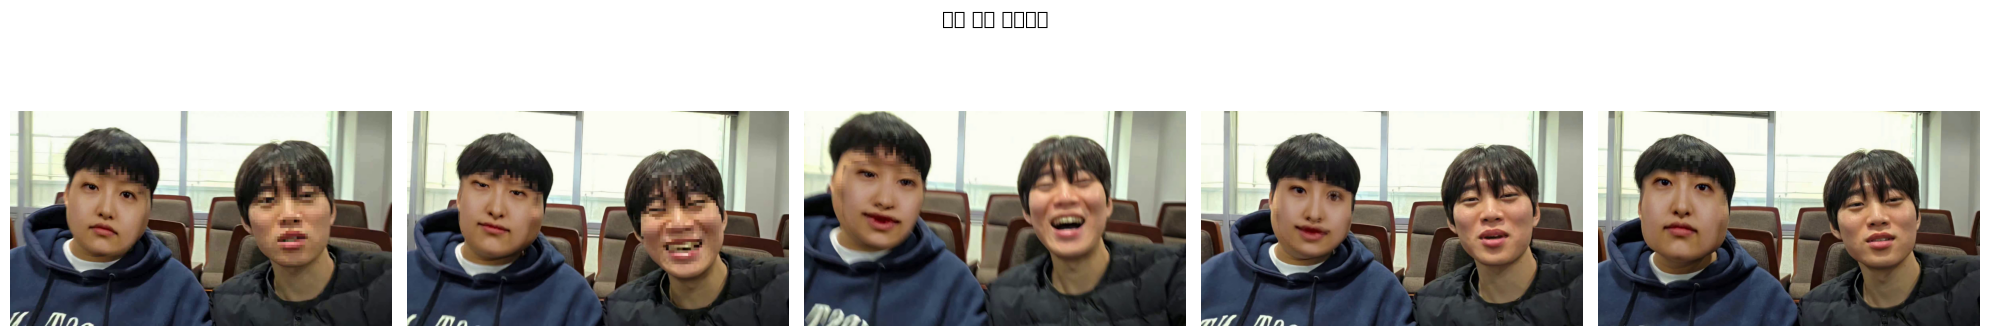


📥 결과 영상 다운로드


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(OUTPUT_VIDEO)
n_out = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
previews = []
for fi in [0, n_out//4, n_out//2, n_out*3//4, n_out-1]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, fi))
    ret, f = cap.read()
    if ret: previews.append(f)
cap.release()

if previews:
    fig, axes = plt.subplots(1, len(previews), figsize=(20, 4))
    for ax, img in zip(axes, previews):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.suptitle('결과 영상 미리보기', fontsize=14)
    plt.tight_layout()
    plt.show()

print('\n📥 결과 영상 다운로드')
files.download(OUTPUT_VIDEO)